# Loan Approval Prediction

## Project Overview
This project uses machine learning to predict whether a loan application will be Approved or Rejected based on the applicant's financial information.

## Objective
The main objective is to build a classification model that can predict loan approval and identify the important factors affecting the decision.


In [1]:
import os

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.stats import chi2_contingency

from sklearn.base import clone
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    accuracy_score,
    classification_report,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV

sns.set_theme(style="whitegrid")

## Dataset Information

The dataset contains approximately 4,300 loan applications.

It includes information about applicants' income, loan amount, loan term, credit score, assets, education, and employment status.

The target variable is loan_status:
- Approved = 1
- Rejected = 0

In [2]:
df = pd.read_csv("/content/loan_approval_dataset.csv")

# remove extra spaces
df.columns = df.columns.str.strip()
for col in ["education", "self_employed", "loan_status"]:
    df[col] = df[col].str.strip()

# turn text into numbers
df["loan_status"] = df["loan_status"].map({"Approved": 1, "Rejected": 0})
df["education"] = df["education"].map({"Graduate": 1, "Not Graduate": 0})
df["self_employed"] = df["self_employed"].map({"Yes": 1, "No": 0})

df.head()

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,1,0,9600000,29900000,12,778,2400000,17600000,22700000,8000000,1
1,2,0,0,1,4100000,12200000,8,417,2700000,2200000,8800000,3300000,0
2,3,3,1,0,9100000,29700000,20,506,7100000,4500000,33300000,12800000,0
3,4,3,1,0,8200000,30700000,8,467,18200000,3300000,23300000,7900000,0
4,5,5,0,1,9800000,24200000,20,382,12400000,8200000,29400000,5000000,0


In [3]:
print("Rows and columns:", df.shape)
print("Missing values:", df.isnull().sum().sum())
print("Duplicate rows:", df.duplicated().sum())
df.info()

Rows and columns: (4269, 13)
Missing values: 0
Duplicate rows: 0
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4269 entries, 0 to 4268
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   loan_id                   4269 non-null   int64
 1   no_of_dependents          4269 non-null   int64
 2   education                 4269 non-null   int64
 3   self_employed             4269 non-null   int64
 4   income_annum              4269 non-null   int64
 5   loan_amount               4269 non-null   int64
 6   loan_term                 4269 non-null   int64
 7   cibil_score               4269 non-null   int64
 8   residential_assets_value  4269 non-null   int64
 9   commercial_assets_value   4269 non-null   int64
 10  luxury_assets_value       4269 non-null   int64
 11  bank_asset_value          4269 non-null   int64
 12  loan_status               4269 non-null   int64
dtypes: int64(13)
memory usage: 4

In [4]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
loan_id,4269.0,2.135000e+03,1.232498e+03,1.0,1068.0,2135.0,3202.0,4269.0
no_of_dependents,4269.0,2.498712e+00,1.695910e+00,0.0,1.0,3.0,4.0,5.0
education,4269.0,5.022253e-01,5.000536e-01,0.0,0.0,1.0,1.0,1.0
self_employed,4269.0,5.036308e-01,5.000454e-01,0.0,0.0,1.0,1.0,1.0
income_annum,4269.0,5.059124e+06,2.806840e+06,200000.0,2700000.0,5100000.0,7500000.0,9900000.0
loan_amount,4269.0,1.513345e+07,9.043363e+06,300000.0,7700000.0,14500000.0,21500000.0,39500000.0
loan_term,4269.0,1.090045e+01,5.709187e+00,2.0,6.0,10.0,16.0,20.0
cibil_score,4269.0,5.999361e+02,1.724304e+02,300.0,453.0,600.0,748.0,900.0
residential_assets_value,4269.0,7.472617e+06,6.503637e+06,-100000.0,2200000.0,5600000.0,11300000.0,29100000.0
commercial_assets_value,4269.0,4.973155e+06,4.388966e+06,0.0,1300000.0,3700000.0,7600000.0,19400000.0


## Exploratory Data Analysis

Exploratory Data Analysis was performed to understand the dataset and identify relationships between the features and loan approval.

The analysis includes:
- Distribution of the target variable.
- Distribution of numerical features.
- Correlation between variables.
- Relationship between credit score and loan approval.
- Relationship between loan amount and loan approval.

loan_status
1    0.622
0    0.378
Name: proportion, dtype: float64


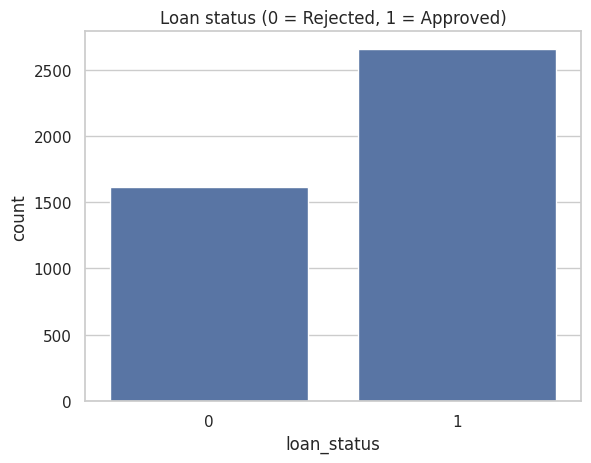

In [5]:
print(df["loan_status"].value_counts(normalize=True).round(3))

sns.countplot(x="loan_status", data=df)
plt.title("Loan status (0 = Rejected, 1 = Approved)")
plt.show()

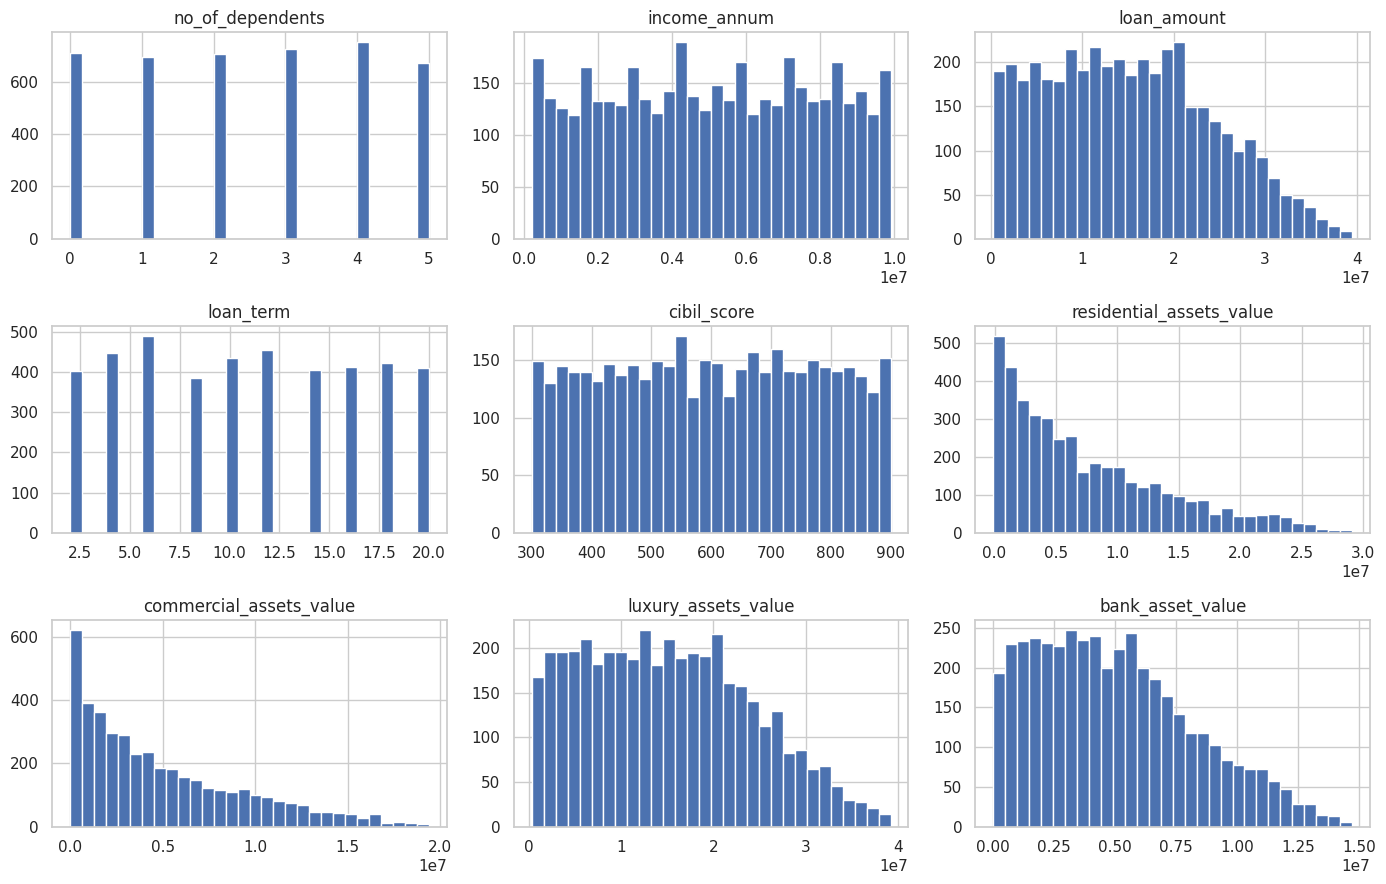

In [6]:
number_columns = ["no_of_dependents", "income_annum", "loan_amount", "loan_term", "cibil_score",
                  "residential_assets_value", "commercial_assets_value",
                  "luxury_assets_value", "bank_asset_value"]

df[number_columns].hist(bins=30, figsize=(14, 9))
plt.tight_layout()
plt.show()

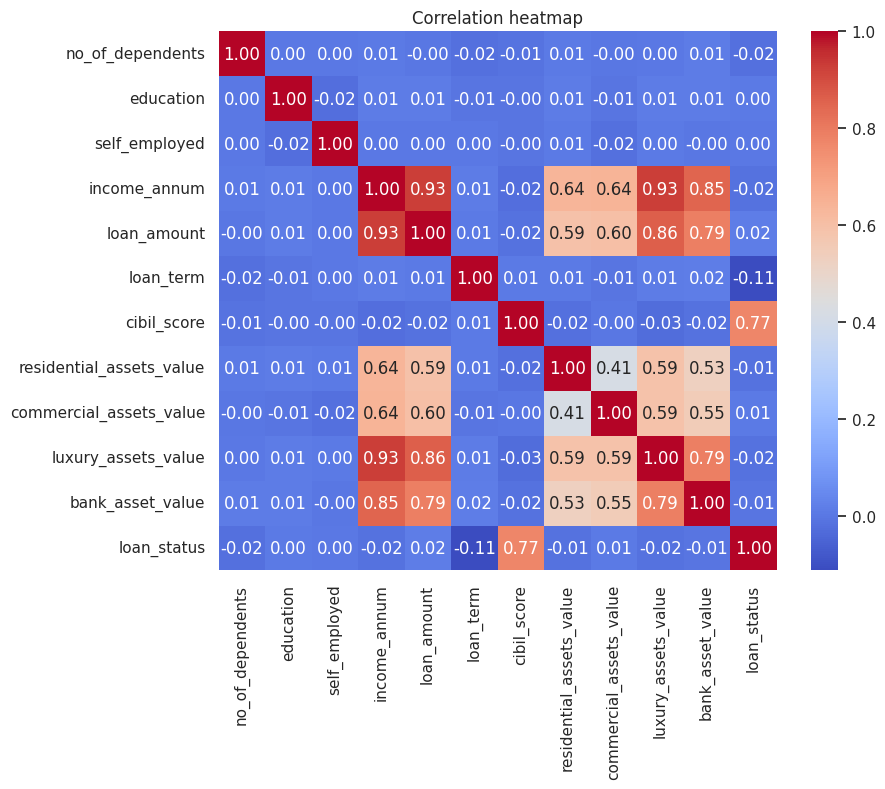

In [7]:
# Correlation heatmap (loan_id is only a row number, so we leave it out)
plt.figure(figsize=(9, 7))
sns.heatmap(df.drop(columns="loan_id").corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation heatmap")
plt.show()

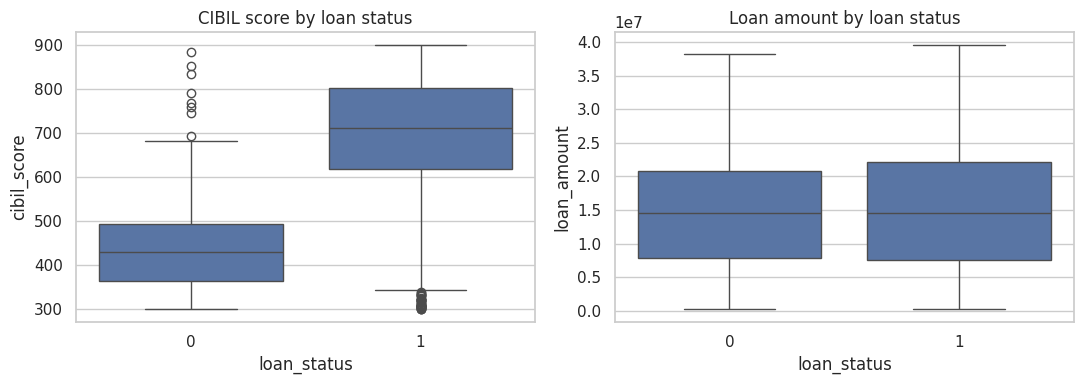

In [8]:
# Credit score and loan amount for approved vs rejected loans
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
sns.boxplot(x="loan_status", y="cibil_score", data=df, ax=axes[0])
axes[0].set_title("CIBIL score by loan status")
sns.boxplot(x="loan_status", y="loan_amount", data=df, ax=axes[1])
axes[1].set_title("Loan amount by loan status")
plt.tight_layout()
plt.show()

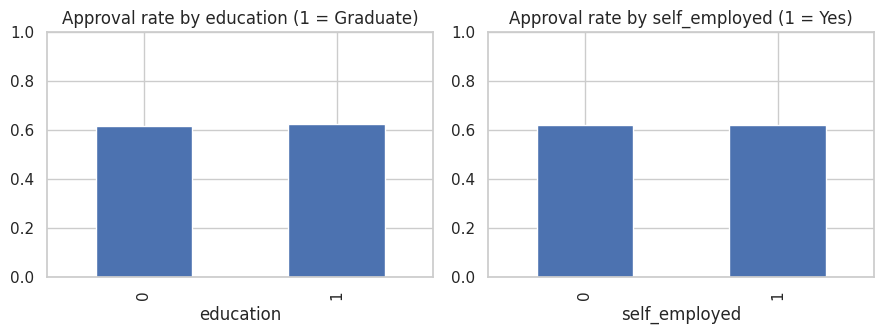

In [9]:
# Approval rate for education and self-employment
fig, axes = plt.subplots(1, 2, figsize=(9, 3.5))
df.groupby("education")["loan_status"].mean().plot(kind="bar", ax=axes[0], title="Approval rate by education (1 = Graduate)")
df.groupby("self_employed")["loan_status"].mean().plot(kind="bar", ax=axes[1], title="Approval rate by self_employed (1 = Yes)")
axes[0].set_ylim(0, 1)
axes[1].set_ylim(0, 1)
plt.tight_layout()
plt.show()

## Feature Selection

The features were selected based on their relevance to loan approval.

The loan_id column was removed because it is only an identifier and does not provide useful information for prediction.

A chi-square test was used to examine the relationship between categorical variables and loan approval.

Outliers were retained because large asset and income values may represent genuine high-income applicants.

In [10]:
p_education = chi2_contingency(pd.crosstab(df["education"], df["loan_status"]))[1]
p_self_employed = chi2_contingency(pd.crosstab(df["self_employed"], df["loan_status"]))[1]
print("education p-value:    ", round(p_education, 3))
print("self_employed p-value:", round(p_self_employed, 3))

columns_to_drop = ["loan_id", "loan_status"]
if p_education > 0.05:
    columns_to_drop.append("education")
    print("education is not linked to approval, so it is dropped")
if p_self_employed > 0.05:
    columns_to_drop.append("self_employed")
    print("self_employed is not linked to approval, so it is dropped")

education p-value:     0.772
self_employed p-value: 1.0
education is not linked to approval, so it is dropped
self_employed is not linked to approval, so it is dropped


## Train-Test Split

The dataset was divided into training and testing sets.

80% of the data was used for training and 20% was reserved for testing.

Stratified splitting was used to maintain a similar proportion of approved and rejected applications in both datasets.

In [11]:
X = df.drop(columns=columns_to_drop)
y = df["loan_status"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print("Features used:", list(X.columns))
print("Training rows:", len(X_train), "| Test rows:", len(X_test))

Features used: ['no_of_dependents', 'income_annum', 'loan_amount', 'loan_term', 'cibil_score', 'residential_assets_value', 'commercial_assets_value', 'luxury_assets_value', 'bank_asset_value']
Training rows: 3415 | Test rows: 854


## Machine Learning Models

Three classification algorithms were compared:

1. Logistic Regression
2. Random Forest
3. Gradient Boosting

Each model has different strengths and is evaluated to determine which performs best on the loan approval dataset.

In [12]:
logistic = make_pipeline(
    StandardScaler(),
    LogisticRegression(max_iter=1000, class_weight="balanced"),
)
forest = RandomForestClassifier(class_weight="balanced", random_state=42)
boosting = GradientBoostingClassifier(random_state=42)

# Step 2: the settings to try for each model
logistic_grid = {"logisticregression__C": [0.01, 0.1, 1, 10]}

forest_grid = {
    "n_estimators": [100, 300],
    "max_depth": [5, 10, None],
    "min_samples_leaf": [1, 5, 10],
}

boosting_grid = {
    "n_estimators": [100, 200],
    "learning_rate": [0.05, 0.1],
    "max_depth": [2, 3],
}

## Hyperparameter Tuning

GridSearchCV was used to find the best hyperparameters for each machine learning model.

Five-fold cross-validation was performed on the training data.

ROC-AUC was used as the main scoring metric.

The test dataset was kept separate and was not used during hyperparameter tuning.

In [13]:
searches = {
    "Logistic Regression": GridSearchCV(logistic, logistic_grid, cv=5, scoring="roc_auc", n_jobs=-1),
    "Random Forest": GridSearchCV(forest, forest_grid, cv=5, scoring="roc_auc", n_jobs=-1),
    "Gradient Boosting": GridSearchCV(boosting, boosting_grid, cv=5, scoring="roc_auc", n_jobs=-1),
}

for name, search in searches.items():
    search.fit(X_train, y_train)
    print(name)
    print("  best CV ROC-AUC:", round(search.best_score_, 4))
    print("  best settings:  ", search.best_params_)

Logistic Regression
  best CV ROC-AUC: 0.9669
  best settings:   {'logisticregression__C': 10}
Random Forest
  best CV ROC-AUC: 0.9976
  best settings:   {'max_depth': 10, 'min_samples_leaf': 5, 'n_estimators': 100}
Gradient Boosting
  best CV ROC-AUC: 0.9973
  best settings:   {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100}


In [14]:
models = {name: search.best_estimator_ for name, search in searches.items()}

best_name = max(searches, key=lambda name: searches[name].best_score_)
best_model = models[best_name]
print("Best model (highest CV score):", best_name)

Best model (highest CV score): Random Forest


## Model Evaluation

The trained models were evaluated using:

- Accuracy
- Precision
- Recall
- F1-score
- ROC-AUC
- Confusion Matrix
- ROC Curve

Train and test ROC-AUC scores were also compared to identify possible overfitting.

In [15]:
rows = []
for name, model in models.items():
    pred = model.predict(X_test)
    prob = model.predict_proba(X_test)[:, 1]
    rows.append({
        "model": name,
        "accuracy": accuracy_score(y_test, pred),
        "precision": precision_score(y_test, pred),
        "recall": recall_score(y_test, pred),
        "f1": f1_score(y_test, pred),
        "test_roc_auc": roc_auc_score(y_test, prob),
        "train_roc_auc": roc_auc_score(y_train, model.predict_proba(X_train)[:, 1]),
    })

results = pd.DataFrame(rows).set_index("model").round(4)
results

,accuracy,precision,recall,f1,test_roc_auc,train_roc_auc
model,,,,,,
Logistic Regression,0.9215,0.9531,0.9190,0.9358,0.9734,0.9675
Random Forest,0.9789,0.9849,0.9812,0.9830,0.9988,0.9996
Gradient Boosting,0.9836,0.9832,0.9906,0.9869,0.9976,0.9999


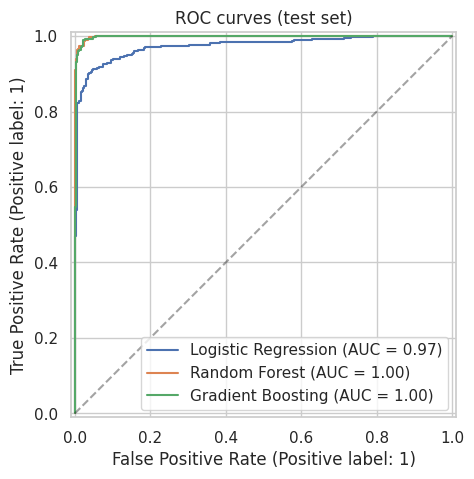

In [16]:
fig, ax = plt.subplots(figsize=(6, 5))
for name, model in models.items():
    RocCurveDisplay.from_estimator(model, X_test, y_test, name=name, ax=ax)
ax.plot([0, 1], [0, 1], "k--", alpha=0.4)
ax.set_title("ROC curves (test set)")
plt.show()

Best model: Random Forest 

              precision    recall  f1-score   support

    Rejected       0.97      0.98      0.97       323
    Approved       0.98      0.98      0.98       531

    accuracy                           0.98       854
   macro avg       0.98      0.98      0.98       854
weighted avg       0.98      0.98      0.98       854



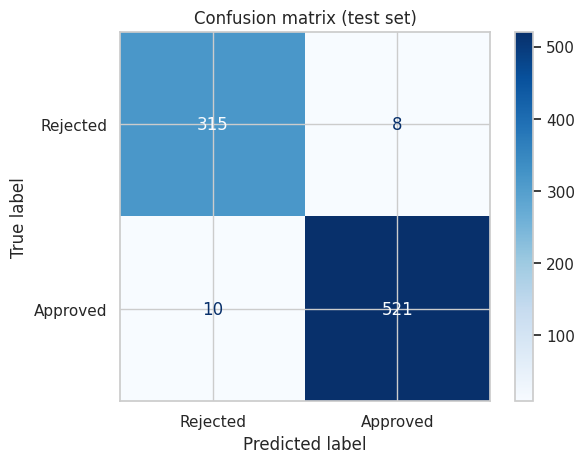

In [17]:
y_pred = best_model.predict(X_test)
y_prob = best_model.predict_proba(X_test)[:, 1]

print("Best model:", best_name, "\n")
print(classification_report(y_test, y_pred, target_names=["Rejected", "Approved"]))

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred, display_labels=["Rejected", "Approved"], cmap="Blues"
)
plt.title("Confusion matrix (test set)")
plt.show()

## Feature Importance

Permutation importance was used to identify the features that have the greatest influence on the model's predictions.

A larger decrease in model performance after shuffling a feature indicates that the model relies more heavily on that feature.

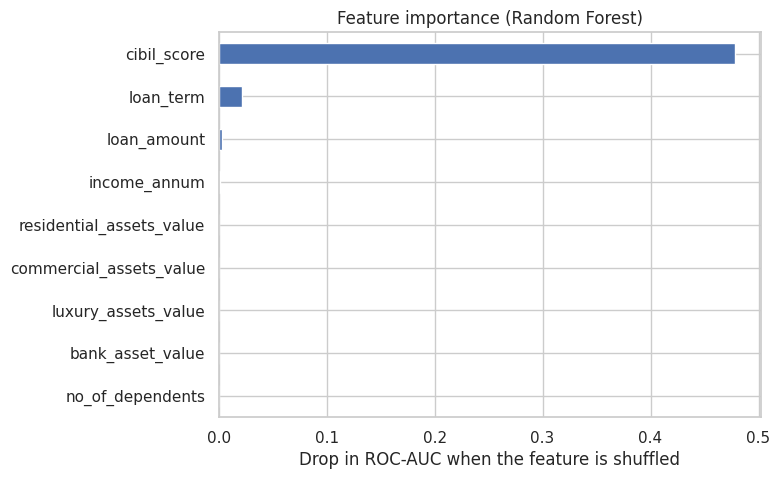

In [18]:
result = permutation_importance(
    best_model, X_test, y_test, scoring="roc_auc", n_repeats=10, random_state=42
)

importance = pd.Series(result.importances_mean, index=X.columns).sort_values()
importance.plot(kind="barh", figsize=(7, 5))
plt.xlabel("Drop in ROC-AUC when the feature is shuffled")
plt.title(f"Feature importance ({best_name})")
plt.show()

## CIBIL Score Analysis

CIBIL score is expected to be an important factor in loan approval.

To understand its contribution, the model was evaluated with and without the cibil_score feature.

This comparison helps determine how much the model depends on credit score.

In [19]:
model_without_cibil = clone(best_model)
model_without_cibil.fit(X_train.drop(columns="cibil_score"), y_train)

prob_without = model_without_cibil.predict_proba(X_test.drop(columns="cibil_score"))[:, 1]

print("Test ROC-AUC with CIBIL score:   ", round(roc_auc_score(y_test, y_prob), 4))
print("Test ROC-AUC without CIBIL score:", round(roc_auc_score(y_test, prob_without), 4))

Test ROC-AUC with CIBIL score:    0.9988
Test ROC-AUC without CIBIL score: 0.6019


In [20]:
import shap

# A small sample keeps this fast
background = X_train.sample(100, random_state=42)   # reference data
samples = X_test.sample(200, random_state=42)       # applicants to explain


def approval_probability(data):
    return best_model.predict_proba(data)[:, 1]


explainer = shap.Explainer(approval_probability, background)
shap_values = explainer(samples)

print("Applicants explained x features:", shap_values.shape)

ExactExplainer explainer: 201it [00:41,  4.39it/s]

Applicants explained x features: (200, 9)


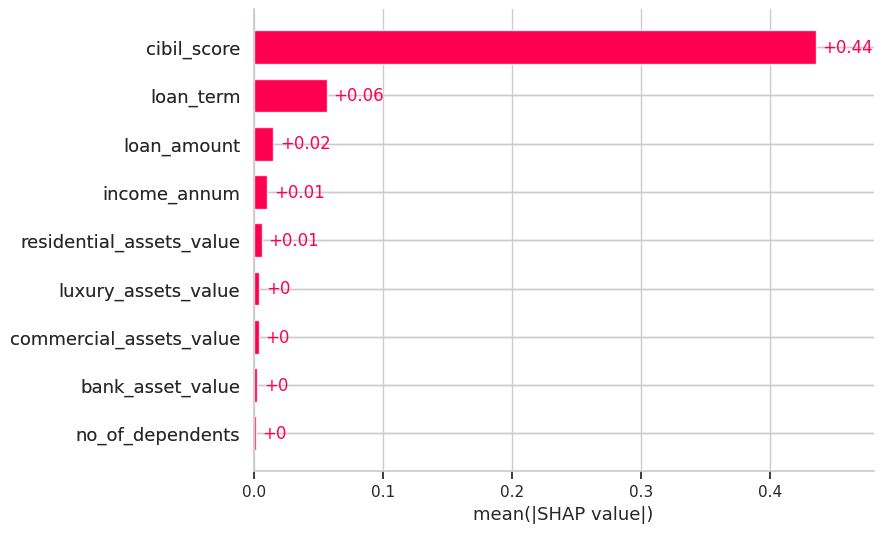

In [21]:
shap.plots.bar(shap_values)

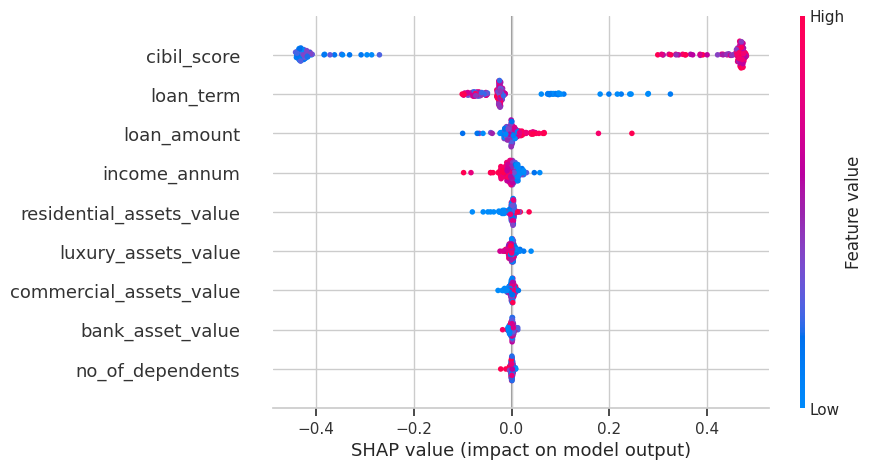

In [22]:
shap.plots.beeswarm(shap_values)

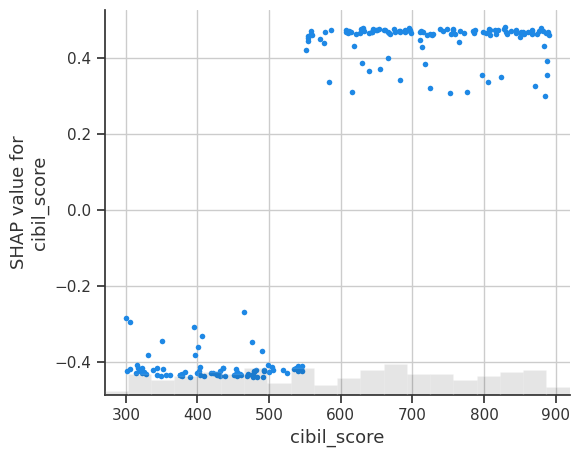

In [23]:
shap.plots.scatter(shap_values[:, "cibil_score"])

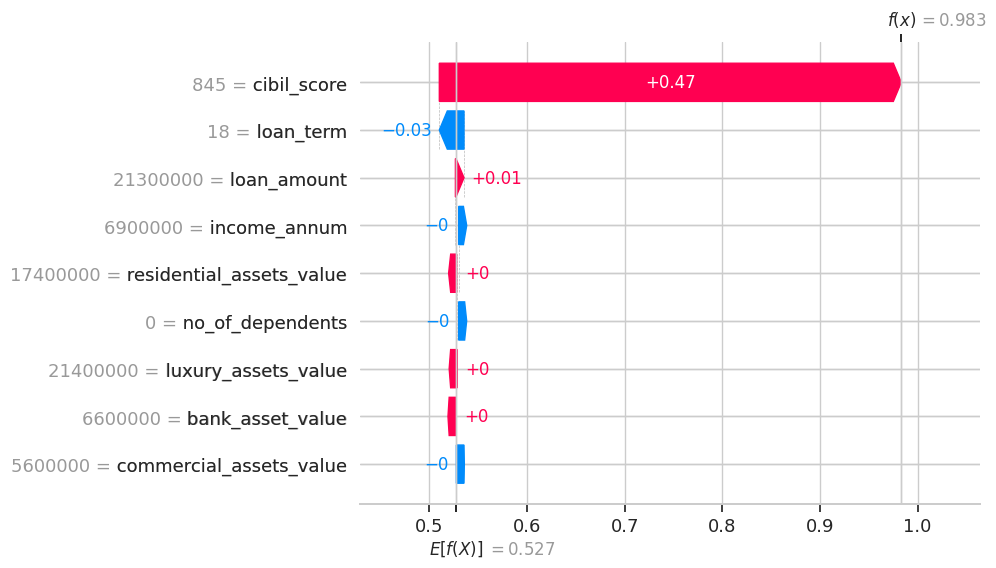

In [24]:
shap.plots.waterfall(shap_values[0])

## Saving the Model

After selecting the best-performing model, it was saved using Joblib.

The saved model can be loaded later and used to make predictions on new loan applications.

In [28]:
joblib.dump(best_model, "models/loan_model.pkl")

['models/loan_model.pkl']

In [27]:
os.makedirs("models", exist_ok=True)
joblib.dump(best_model, "models/loan_model.pkl")

# Test: load it back and predict for one applicant
model = joblib.load("models/loan_model.pkl")
one_applicant = X_test.iloc[[0]]
print(one_applicant.T)

result = model.predict(one_applicant)[0]
print("\nPrediction:", "Approved" if result == 1 else "Rejected")
print("Probability of approval:", round(model.predict_proba(one_applicant)[0, 1], 3))

                              2856
no_of_dependents                 3
income_annum               8300000
loan_amount               31400000
loan_term                        6
cibil_score                    674
residential_assets_value   1000000
commercial_assets_value    1600000
luxury_assets_value       17200000
bank_asset_value           6100000

Prediction: Approved
Probability of approval: 0.926


## Conclusion

The machine learning models were trained and compared using several evaluation metrics.

The best model was selected based on its cross-validation and test performance.

The analysis also identified the most important features affecting loan approval and examined the effect of removing the CIBIL score.

The final trained model was saved for future prediction and deployment.